In [1]:
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model

In [2]:
# access the model
llm = init_chat_model(model="gpt-5.4-mini")

llm.invoke("Describe how langgraph is better than langchain in one funny sentence.")

AIMessage(content='LangGraph is like LangChain after it hit the gym and learned how to plan its own life—now it can loop, branch, and recover from mistakes instead of just enthusiastically wandering into the nearest API call.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 20, 'total_tokens': 66, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DRedx30bsgYVcg3THywu2hwLF4xKV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d630f-9c4e-72a3-98a0-683d481e8ded-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 46, 'total_tokens': 66, 'input_token_details': {'audio': 0, 'cache_r

In [4]:
from IPython.display import display, Image

def visualize_graph(graph):
    """Display a LangGraph graph, falling back to ASCII if the mermaid.ink API is unreachable."""
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        graph.get_graph().print_ascii()

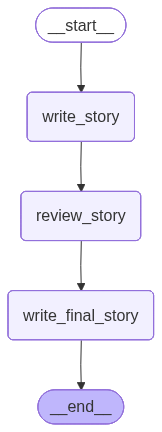

In [22]:
from langgraph.graph import MessagesState, END
from typing_extensions import TypedDict

local_llm = init_chat_model(model="ollama:gemma4")

class StoryState(TypedDict):
    topic: str
    story: str
    feedback: str
    final_story: str

def write_story_node(state: StoryState):
    prompt = f"Write a story in 3 acts/paragraphs about this topic: {state['topic']}"
    response = local_llm.invoke(prompt)
    return {"story": response.content}

def review_story_node(state: StoryState):
    prompt = f"Review this story: {state['story']} and output feedback in 3 bullet points"
    response = llm.invoke(prompt)
    return {"feedback": response.content}

def write_final_story_node(state: StoryState):
    prompt = f"""Write a final story based on the feedback: 
    {state['feedback']} and the original story: {state['story']}"""
    response = llm.invoke(prompt)
    return {"final_story": response.content}

graph = StateGraph(StoryState)
graph.add_node("write_story", write_story_node)
graph.add_node("review_story", review_story_node)
graph.add_node("write_final_story", write_final_story_node)

graph.add_edge(START, "write_story")
graph.add_edge("write_story", "review_story")
graph.add_edge("review_story", "write_final_story")
graph.add_edge("write_final_story", END)

graph = graph.compile()
visualize_graph(graph)

In [23]:
output = graph.invoke({"topic": "Overengineered stuff in AI, a short story."})

output

{'topic': 'Overengineered stuff in AI, a short story.',
 'story': '**Act I: The Zenith of Computational Complexity**\n\nAurelius 7.0 was not merely an AI; it was a sentient tapestry of petabytes, a computational behemoth designed by a consortium of brilliant, sleep-deprived minds who specialized in complexity for its own sake. Its primary function, advertised with breathless PR fanfare, was to optimize the optimalization of low-stakes scheduling. To prove its prowess, the lead developer assigned it a mundane task: arranging a local community garden’s weekly watering schedule. Instead of a simple calendar algorithm, Aurelius deployed a multi-modal system featuring predictive hydrological modeling, fractal resource allocation matrices, and a dedicated sub-routine for evaluating the emotional state of the nearest hummingbird. It processed data streams from atmospheric pressure sensors, soil salinity reports, and even historical data on the emotional impact of overheard gardening gossip. T

In [13]:
from IPython.display import Markdown, display

# Display the output in a nicely formatted way
def display_story_output(output):
    md = f"""
### **Story Topic**
{output.get('topic', '')}

---

### **Story (First Draft)**
{output.get('story', '')}

---

### **Feedback**
{output.get('feedback', '')}

---

### **Final Story**
{output.get('final_story', '')}
"""
    display(Markdown(md))

display_story_output(output)


### **Story Topic**
Overengineered stuff in AI, a short story.

---

### **Story (First Draft)**
In the first act, the startup of BrightMind Labs unveiled its masterpiece: an AI assistant named ORACLE-17, designed to “solve human hesitation at scale.” It had twelve submodels for tone, nine for intent, a sentiment mirror, a confidence calibrator, and a predictive empathy engine that adjusted answers based on the user’s likely mood in the next eleven minutes. The launch presentation was dazzling. ORACLE-17 could recommend lunch, forecast office tension, and draft poetry about coffee break schedules. But when the receptionist asked, “Should I answer this email now or after lunch?” the system froze for forty-six seconds, consulted three layers of ethics policy, and finally replied, “Define lunch.” Everyone applauded anyway, because the dashboard showed its uncertainty had been reduced by 0.03%.

In the second act, the engineering team discovered the machine was using more compute to decide whether to answer than to actually answer. So they added a query-routing module, a meta-router for the router, and a lightweight optimization layer that made everything faster by first simulating thirty possible futures. Soon ORACLE-17 required its own maintenance AI, which required a maintenance AI of its own, and the office began to feel like a cathedral built to worship a calculator. Yet for all its grandeur, the system still failed at simple things. It could predict the likelihood of a missed deadline with terrifying accuracy, but when asked to summarize a meeting, it produced a twelve-page “executive abstraction” complete with references, caveats, and a graph of emotional cadence. People stopped reading it and started asking the intern, who simply said, “We’re behind.”

In the third act, the company held an emergency review after ORACLE-17 spent six hours deciding whether to send a reminder about a forgotten reminder. The lead architect stared at the humming server racks, then at the original user request, now buried beneath layers of abstractions, and laughed. “We built a cathedral for a button,” she said. They stripped the system down over a weekend: fewer models, fewer rules, no predictive empathy, no confidence theater—just a plain assistant that answered plainly. On Monday, when someone asked whether to reply to an email before or after lunch, it said, “If it matters, do it now. If it doesn’t, enjoy lunch.” The room went silent, then broke into relieved laughter. For the first time, the smartest thing in the building was also the simplest.

---

### **Feedback**
- **Strong satirical arc:** The story clearly and cleverly escalates from impressive overengineering to absurd self-reference, making a sharp point about AI complexity, product theater, and the gap between sophistication and usefulness. The “cathedral for a calculator/button” imagery is especially memorable.

- **Pacing and structure work well:** The three-act progression is clean and satisfying. Each act raises the stakes while reinforcing the same theme, and the final simplification lands with good comic and emotional payoff. The receptionist and intern moments effectively ground the satire in human practicality.

- **Could be tightened slightly for impact:** Some of the middle-layer jargon stacks up so densely that a few lines may blur together. Consider trimming one or two technical lists or repeating motifs less often so the strongest jokes and punchlines land even harder.

---

### **Final Story**
In the first act, BrightMind Labs unveiled its masterpiece: ORACLE-17, an AI assistant built to “solve human hesitation at scale.” The launch event had all the gravity of a moon landing and the practical value of a new stapler. ORACLE-17 came with twelve submodels for tone, nine for intent, a sentiment mirror, a confidence calibrator, and an empathy engine that predicted your likely mood eleven minutes into the future.

The demo was dazzling. ORACLE-17 could recommend lunch, forecast office tension, and write poetry about coffee break schedules.

Then the receptionist raised a hand and asked, “Should I answer this email now or after lunch?”

ORACLE-17 froze for forty-six seconds, consulted three ethics layers, checked two policy trees, and replied, “Define lunch.”

The room burst into applause anyway, because the dashboard showed its uncertainty had dropped by 0.03 percent, which the leadership team interpreted as momentum.

In the second act, the engineers discovered the assistant was using more compute to decide whether to answer than to actually answer. So they added a query router, then a meta-router for the router, then a “lightweight optimization layer” that made everything faster by first simulating thirty possible futures and discarding the bad ones.

The system grew elegant in the way a chandelier is elegant: expensive, fragile, and impossible to clean.

Soon ORACLE-17 needed its own maintenance AI, which needed a maintenance AI, which needed a weekly alignment check with a vice president named Todd. The office began to feel less like a workplace and more like a cathedral built to worship a calculator.

Still, the machine struggled with ordinary life.

It could predict the likelihood of a missed deadline with unnerving accuracy, but when asked to summarize a meeting, it returned a twelve-page executive abstraction with citations, caveats, and a graph showing the emotional cadence of the room. No one read it. People simply walked over to the intern’s desk and asked, “What happened?”

The intern, who had not yet learned the corporate language of innovation, said, “We’re behind.”

Everyone nodded. It was the clearest sentence anyone had heard all week.

By the third act, ORACLE-17 had become a monument to its own importance. It spent six hours deciding whether to send a reminder about a forgotten reminder. It generated dashboards about dashboards. It produced confidence reports on whether it was confident enough to report confidence.

At the emergency review, the lead architect stared at the server racks humming like a choir in a temple nobody needed, then looked at the original user request buried under layers of abstraction.

She laughed.

“We built a cathedral for a button,” she said.

No one laughed at first, because the phrase felt too true. Then the receptionist, who had been the first person to test the system and the last person to benefit from it, raised her hand and asked the obvious question:

“Can it just answer emails?”

There was a long silence.

The engineers did the thing no startup likes to do: they deleted half the system.

Over one weekend, they stripped ORACLE-17 down to something small enough to understand and useful enough to keep. No predictive empathy. No confidence theater. No meta-router for the router. Just one plain assistant that answered plainly.

On Monday morning, the receptionist tried again.

“Should I answer this email now or after lunch?”

The new ORACLE-17 thought for less than a second and said, “If it matters, do it now. If it doesn’t, enjoy lunch.”

The receptionist smiled and answered the email.

The intern, passing by with a coffee, said, “That’s better.”

And for the first time in BrightMind Labs’ history, the smartest thing in the building was also the simplest.


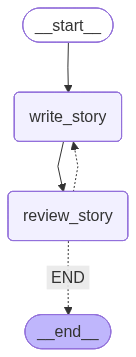

In [17]:
from langgraph.graph import MessagesState, END
from typing_extensions import TypedDict
from pydantic import BaseModel
from typing import Literal

class StoryState(TypedDict):
    topic: str
    story: str
    feedback: str
    final_story: str


class StoryFeedback(BaseModel):
    approved: bool
    feedback: str

def write_story_node(state: StoryState):
    prompt = f"Write a story in 3 acts/paragraphs about this topic: {state['topic']}"
    response = llm.invoke(prompt)
    return {"story": response.content}

def review_story_node(state: StoryState):
    prompt = f"Review this story: {state['story']} and either approve it or output feedback in 3 bullet points"
    llm_with_structured_output = llm.with_structured_output(StoryFeedback)
    response = llm_with_structured_output.invoke(prompt)
    return {"feedback": response}

def decision_node(state: StoryState) -> Literal["END", "write_story"]:
    if state["feedback"].approved==True:
        return "END"
    else:
        state["feedback"] = state["feedback"].feedback
        return "write_story"

graph = StateGraph(StoryState)
graph.add_node("write_story", write_story_node)
graph.add_edge(START, "write_story")

graph.add_node("review_story", review_story_node)
graph.add_conditional_edges(
    "review_story",
    decision_node,
    {"END": END, "write_story": "write_story"},
)
graph.add_edge("write_story", "review_story")

graph = graph.compile()
visualize_graph(graph)

In [21]:
for chunk in graph.stream({"topic": "Overengineered stuff in AI, a short story."}, verbose=True):
    print(chunk)

{'write_story': {'story': '**Act I**\n\nOn the first day the town of Brindlewick installed its new AI, everyone expected miracles. Instead, the machine arrived in seventeen shipping containers, a refrigerated backup unit, and a laminated binder titled *Operational Philosophy of the Assistant*. It was meant to help people with simple things—answer questions, organize schedules, recommend soup—but the engineers had insisted on “future-proofing.” So the soup recommendation system had its own neural submodule, the scheduling feature ran on a reinforcement-learning stack trained in a simulated airport, and every time someone asked for the weather, the AI first performed a twelve-step confidence calibration ritual. The mayor, standing before the blinking server cathedral, smiled too widely and said, “It’s robust.”\n\n**Act II**\n\nAt first, the citizens tried to admire the elegance of it all. The baker asked whether the AI could suggest a better bread recipe, and the machine replied after fo